# 05 - Impact Events & Melting Conditions

This notebook establishes the thermodynamic conditions (P, T) for impact events during post-gas-disk accretion, covering both global and partial melting processes.

It covers:
- Loading post-disk collision histories from `04_accretion_history.xlsx`
- Classifying impact events as **small**, **global**, or **partial** melting using `ImpactEventProcessor`
- Updating global melting processes (magma_ocean) with a cooling duration
- Updating partial melting pool (large) via `ad.update_partial_melting_process()`
- Visualizing mass and equilibration pressure evolution colored by event type
- Exporting processed impact event tables to Excel

> **Prerequisites:** Run `01` → `04` notebooks first.  
> **Input:** `./Tables/04_accretion_history.xlsx`  
> **Output:** `./Tables/05_impact_events.xlsx`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
from matplotlib.lines import Line2D
sys.path.append('../../src')
import accrediff as ad

# ── Plot style ──────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
})

print("Setup complete.")

Setup complete.


## 1. Load Accretion History

Load the post-disk collision history table exported by `04_accretion_history.ipynb`.  
Each sheet corresponds to one planet (`planets_1`, `planets_2`, ...).

In [2]:
# ── Load accretion history ───────────────────────────────
accretion_file = './Tables/04_accretion_history.xlsx'
D = pd.read_excel(accretion_file, sheet_name=None)

print(f"Loaded: {accretion_file}")
print(f"Planets: {list(D.keys())}")

Loaded: ./Tables/04_accretion_history.xlsx
Planets: ['planets_1', 'planets_2', 'planets_3']


## 2. Classify Impact Events & Update Global Melting

For each planet:
- `ImpactEventProcessor` classifies each collision as **small** or **global** melting based on:
  - `p_ratio` — pressure ratio for small impacts (P = p_ratio × P_CMB)
  - `Mtotal` — mass threshold for global melting
  - `ratio` — impactor-to-target mass ratio range
- `update_global_melting_process(duration)` propagates the thermal effect of global melting events over a cooling duration (Myr)

In [3]:
data_dict = {}

for key in D.keys():
    df = D[key]
    # Initialize processor and classify events
    processor = ad.ImpactEventProcessor(
        df, p_ratio=0.6, Mtotal=0.1, ratio=[0.1, 0.5]
    )
    df_CE = processor.df_CE
    # Propagate global melting thermal effect (cooling duration = 5 Myr)
    df_CE = processor.update_global_melting_process(duration=5)
    data_dict[key] = df_CE

print("Global melting classification complete.")
print(f"Event type counts (planets_1):")
print(data_dict[list(data_dict.keys())[0]]['events'].value_counts())

Global melting classification complete.
Event type counts (planets_1):
events
small     139
global      3
Name: count, dtype: int64


## 3. Update Partial Melting Pool

`ad.update_partial_melting_process()` identifies **partial** melting events between global melting episodes,  
where the planet is not fully molten but residual heat still allows partial re-equilibration.

Event types after this step (see kong+ 2026 Fig.3):
| Type | Description |
|------|-------------|
| `small` | Small impact, local equilibration at P_2 = p_ratio × P_CMB | 
| `global` | Post-large impact, magma ocean, equilibration at P_4 = 0.5 * P_MO | 
| `partial` | Large impact, melting pool, equilibration at P_3  |

In [4]:
for key in data_dict.keys():
    data_dict[key] = ad.update_partial_melting_process(data_dict[key])

print("Partial melting update complete.")
print(f"Event type counts (planets_1):")
print(data_dict[list(data_dict.keys())[0]]['events'].value_counts())

Partial melting update complete.
Event type counts (planets_1):
events
small      139
global       2
partial      1
Name: count, dtype: int64


## 4. Visualize Mass Evolution by Event Type

Plot the mass evolution of the **largest planet** in each simulation.  
Marker colors indicate event type:
- ⚫ Black — small impact
- 🟠 Orange — global melting
- ★ Red star — partial melting

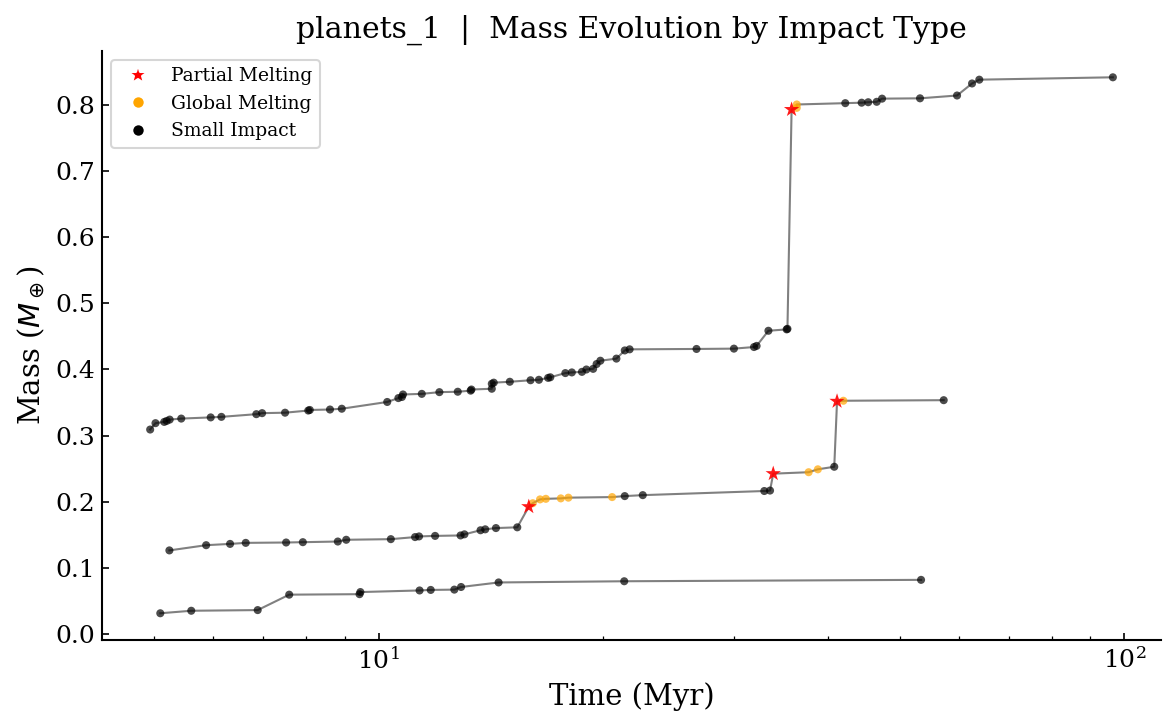

In [5]:
legend_handles = [
    Line2D([0], [0], marker='*', color='w', label='Partial Melting',
           markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Global Melting',
           markerfacecolor='orange', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Small Impact',
           markerfacecolor='black', markersize=6),
]

fig, ax = plt.subplots(figsize=(8, 5))

for key in data_dict.keys():
    df1        = data_dict[key]
    planet_id  = df1['target_id'].iloc[-1]
    df_planet  = df1[df1['target_id'] == planet_id]

    x = df_planet['Time']
    y = df_planet['Mass']

    mask_small   = df_planet['events'] == 'small'
    mask_global  = df_planet['events'] == 'global'
    mask_partial = df_planet['events'] == 'partial'

    ax.plot(x, y, c='grey', linewidth=1, zorder=3)
    ax.scatter(x[mask_small],   y[mask_small],   c='black',  s=15, alpha=0.7, edgecolors='none', zorder=4)
    ax.scatter(x[mask_global],  y[mask_global],  c='orange', s=15, alpha=0.7, edgecolors='none', zorder=4)
    ax.scatter(x[mask_partial], y[mask_partial], c='red',    s=60, marker='*', alpha=0.9, edgecolors='none', zorder=5)

ax.set_xscale('log')
ax.set_xlabel('Time (Myr)')
ax.set_ylabel('Mass ($M_\\oplus$)')
ax.set_title(f'{list(data_dict.keys())[0]}  |  Mass Evolution by Impact Type')
ax.legend(handles=legend_handles, fontsize=9, loc='best', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Export Results

Save the fully classified impact event table to Excel.  
Each planet occupies a separate sheet.  
The file is saved to `./Tables/05_impact_events.xlsx`.

In [6]:
import pathlib

save_dir  = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)

save_file = save_dir / '05_impact_events.xlsx'
with pd.ExcelWriter(save_file) as writer:
    for key, df in data_dict.items():
        df.to_excel(writer, sheet_name=key, index=False)

print(f"Saved: {save_file}")

# Verify
df_check = pd.read_excel(save_file, sheet_name=None)
print(f"Sheets: {list(df_check.keys())}")

Saved: Tables/05_impact_events.xlsx
Sheets: ['planets_1', 'planets_2', 'planets_3']


## 6. Quick Inspection

Preview global and partial melting events for the first planet.

In [7]:
df_p1 = df_check[list(df_check.keys())[0]]

print("=== Global Melting Events ===")
display(df_p1[df_p1['events'] == 'global'])

print("=== Partial Melting Events ===")
display(df_p1[df_p1['events'] == 'partial'])

=== Global Melting Events ===


,Time,target_id,impactor_id,m_target,m_impactor,Mass,Impact ratio,events,P_equil,T_equil,k_mantle
126,36.365901,4189,5796,0.792897,0.002547,0.795444,0.003202,global,40.774535,3043.196861,1.0
127,36.371478,4189,5750,0.795444,0.005091,0.800535,0.006359,global,40.774535,3043.196861,1.0


=== Partial Melting Events ===


,Time,target_id,impactor_id,m_target,m_impactor,Mass,Impact ratio,events,P_equil,T_equil,k_mantle
125,35.791791,4189,93,0.461355,0.331542,0.792897,0.41814,partial,91.652688,4119.326178,1.0


## 7. Summary

| Step | Operation | Output |
|------|-----------|--------|
| 1 | Load accretion history | `D` (dict of DataFrames) |
| 2 | Classify small / global melting events | `data_dict` with `ImpactEventProcessor` |
| 3 | Update partial melting pool | `data_dict` with `partial` events added |
| 4 | Visualize mass evolution by event type | scatter + line plot |
| 5 | Export to Excel | `./Tables/05_impact_events.xlsx` |

➡️ **Next:** `06_differentiation.ipynb`